# Mean-Reversion Backtester — built to tell you the truth

**Strategy:** Larry Connors' RSI-2 (a real, documented rule), long-only.

- Trade only when price is **above its 200-day SMA** (mean-revert inside an uptrend — never catch a falling knife)
- **Enter** when RSI(2) < 10 (short-term oversold)
- **Exit** when price closes back above its 5-day SMA (reverted)

**The point of this notebook is NOT to make money.** It is to learn to measure a strategy *honestly*, so you don't fool yourself. The four things that separate a real backtest from a flattering lie:

1. **No look-ahead** — decide on yesterday's signal, trade at today's price
2. **Real Indian costs** — STT, exchange, GST, stamp, slippage
3. **Out-of-sample split** — judge on data the rule never "saw"
4. **Benchmark** — beat buy-and-hold, not just zero

Run the cells top to bottom. The interesting parts are the **experiments** near the end — that's where the real lessons live.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

Matplotlib is building the font cache; this may take a moment.


## 2. Data

This notebook ships with **synthetic data** that has a *known* mean-reversion effect baked in — so you can confirm the engine detects an edge that genuinely exists before you trust it on real data.

To run on **real NSE data on your own machine** (where Yahoo Finance is reachable):

```python
# pip install yfinance
import yfinance as yf
def get_data():
    df = yf.download("SUZLON.NS", start="2018-01-01", end="2024-12-31", progress=False)
    return df[["Close"]].dropna()
```

Just replace `get_data()` below with that, and everything else runs identically.

In [34]:
def make_synthetic(n_days=1500, seed=7):
    """Upward trend + a real short-term mean-reverting wobble (OU process)."""
    rng = np.random.default_rng(seed)
    trend = np.cumsum(np.full(n_days, 0.0003))
    mr = np.zeros(n_days)
    theta, sigma = 0.15, 0.012
    for t in range(1, n_days):
        mr[t] = mr[t-1] * (1 - theta) + rng.normal(0, sigma)
    price = np.exp(4.6 + trend + mr)
    dates = pd.bdate_range("2018-01-01", periods=n_days)
    return pd.DataFrame({"Close": price}, index=dates)

import yfinance as yf
def get_data():
    df = yf.download("SUZLON.NS", start="2021-01-01",
                     end="2026-05-31", progress=False)
    df[["Close"]].dropna()
    if isinstance(df.columns, pd.MultiIndex):        # <-- this check
        df.columns = df.columns.droplevel("Ticker")  # <-- this fix
    return df


raw = get_data()
print(f"{len(raw)} rows, {raw.index[0].date()} to {raw.index[-1].date()}")
raw.head()

1337 rows, 2021-01-01 to 2026-05-29


Price,Close,High,Low,Open,Volume
Date,,,,,
2021-01-01,6.15,6.15,6.15,6.15,2611390
2021-01-04,6.43,6.43,6.43,6.43,4813374
2021-01-05,6.75,6.75,6.11,6.61,62043247
2021-01-06,7.07,7.07,6.98,6.98,12930305
2021-01-07,7.39,7.39,7.39,7.39,4247150


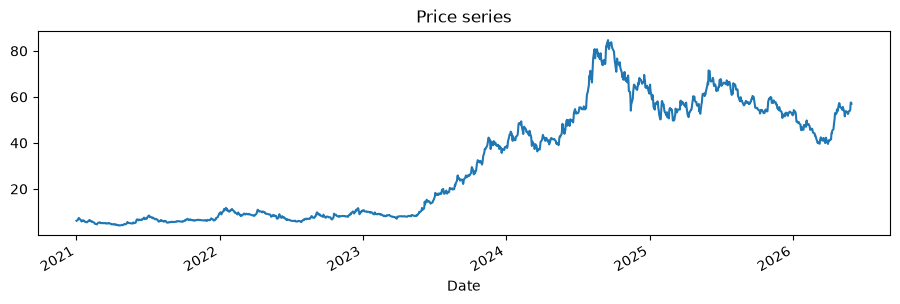

In [35]:
raw["Close"].plot(figsize=(11,3), title="Price series"); plt.show()

## 3. Indicators

RSI(2) is a very short, very twitchy RSI — it swings to extremes fast, which is what we want for short-term oversold signals.

In [36]:
def rsi(series, period=2):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    ag = gain.ewm(alpha=1/period, adjust=False).mean()
    al = loss.ewm(alpha=1/period, adjust=False).mean()
    rs = ag / al.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

def add_indicators(df, rsi_period=2, sma_long=200, sma_exit=5):
    df = df.copy()
    df["sma_long"] = df["Close"].rolling(sma_long).mean()
    df["sma_exit"] = df["Close"].rolling(sma_exit).mean()
    df["rsi"] = rsi(df["Close"], rsi_period)
    return df

df = add_indicators(raw)
df.dropna().head()

Price,Close,High,Low,Open,Volume,sma_long,sma_exit,rsi
Date,,,,,,,,
2021-10-22,6.47,6.66,6.43,6.61,18048809,5.84,6.56,36.87
2021-10-25,6.34,6.57,6.15,6.52,22141652,5.84,6.46,14.78
2021-10-26,6.47,6.57,6.34,6.38,18074253,5.84,6.45,61.23
2021-10-27,6.38,6.52,6.38,6.52,11519622,5.84,6.44,35.46
2021-10-28,6.20,6.43,6.15,6.43,24709500,5.83,6.37,13.21


## 4. Costs — the part beginners skip, and it's why they lose

These are approximate Indian delivery-equity (CNC) costs, charged on **each side** of a round trip. Zerodha delivery brokerage is 0, but STT, slippage, and the rest are very real.

**Slippage (0.15%) is the big one and the most ignored** — you rarely fill at the exact price you saw. Verify these against your own contract notes; they're deliberately on the conservative side.

In [37]:
def cost_fraction_per_side():
    stt      = 0.001       # 0.1%, both buy & sell on delivery
    exchange = 0.0000345   # NSE txn charge
    gst      = 0.18 * exchange
    stamp    = 0.00015
    sebi     = 0.000001
    slippage = 0.0015      # 0.15% — you rarely fill at the exact close
    return stt + exchange + gst + stamp + sebi + slippage

print(f"Round-trip cost: {cost_fraction_per_side()*2*100:.3f}% of trade value")

Round-trip cost: 0.538% of trade value


## 5. The backtest engine

The critical line is the **no-look-ahead** discipline: we read the signal from day `i-1` and execute at day `i`'s price. Using the same day's close to both signal *and* trade is the #1 way people accidentally cheat and get fake results.

In [38]:
def backtest(df, rsi_entry=10, capital=50000):
    df = df.dropna().copy()
    c = cost_fraction_per_side()
    in_pos, entry_price, cash, shares = False, 0.0, capital, 0
    equity_curve, trades = [], []

    closes   = df["Close"].values
    rsis     = df["rsi"].values
    sma_long = df["sma_long"].values
    sma_exit = df["sma_exit"].values
    dates    = df.index

    for i in range(1, len(df)):
        prev_rsi, prev_close = rsis[i-1], closes[i-1]
        prev_smalong, prev_smaexit = sma_long[i-1], sma_exit[i-1]
        exec_price = closes[i]          # proxy for next-day fill

        if not in_pos:
            if (prev_rsi < rsi_entry) and (prev_close > prev_smalong):
                shares = int(cash // (exec_price * (1 + c)))
                if shares > 0:
                    cash -= shares * exec_price * (1 + c)
                    entry_price, in_pos = exec_price, True
        else:
            if prev_close > prev_smaexit:
                cash += shares * exec_price * (1 - c)
                trades.append({"entry": entry_price, "exit": exec_price,
                               "ret_pct": (exec_price/entry_price - 1)*100,
                               "date": dates[i]})
                shares, in_pos = 0, False

        equity_curve.append(cash + shares * exec_price)

    return pd.Series(equity_curve, index=dates[1:]), pd.DataFrame(trades)

## 6. Metrics + benchmark

In [39]:
def metrics(eq, trades, capital, label):
    total = (eq.iloc[-1]/capital - 1)*100
    daily = eq.pct_change().dropna()
    sharpe = daily.mean()/daily.std()*np.sqrt(252) if daily.std()>0 else 0
    dd = ((eq - eq.cummax())/eq.cummax()).min()*100
    n = len(trades)
    win = (trades["ret_pct"]>0).mean()*100 if n else 0
    avg = trades["ret_pct"].mean() if n else 0
    print(f"=== {label} ===")
    print(f"  Final equity : Rs {eq.iloc[-1]:,.0f}  (start {capital:,.0f})")
    print(f"  Total return : {total:7.2f}%")
    print(f"  Sharpe (ann) : {sharpe:7.2f}")
    print(f"  Max drawdown : {dd:7.2f}%")
    print(f"  Trades       : {n}")
    print(f"  Win rate     : {win:7.1f}%")
    print(f"  Avg trade    : {avg:7.2f}%")
    return dict(total=total, sharpe=sharpe, dd=dd, win=win, n=n)

def buy_hold(df, capital):
    df = df.dropna()
    eq = capital * (df["Close"]/df["Close"].iloc[0])
    daily = eq.pct_change().dropna()
    sharpe = daily.mean()/daily.std()*np.sqrt(252) if daily.std()>0 else 0
    dd = ((eq - eq.cummax())/eq.cummax()).min()*100
    return eq, (eq.iloc[-1]/capital-1)*100, sharpe, dd

## 7. The real test: out-of-sample

Split the data 60/40. You'd "develop" your idea on the first 60%. The **last 40% is data the rule never informed** — that's the only result you should believe.

Watch the gap between in-sample and out-of-sample. **A big gap = overfitting.** And watch both against buy-and-hold.

In [40]:
CAP = 50000
df = add_indicators(get_data())
split = int(len(df)*0.60)

eq_is, tr_is = backtest(df.iloc[:split], capital=CAP)
m_is = metrics(eq_is, tr_is, CAP, "IN-SAMPLE (first 60%)")
print()
eq_os, tr_os = backtest(df.iloc[split:], capital=CAP)
m_os = metrics(eq_os, tr_os, CAP, "OUT-OF-SAMPLE (last 40%) <- BELIEVE THIS ONE")

bh_eq, bh_ret, bh_sharpe, bh_dd = buy_hold(df.iloc[split:], CAP)
print(f"\n=== BUY & HOLD (same out-of-sample window) ===")
print(f"  Total return : {bh_ret:7.2f}%")
print(f"  Sharpe (ann) : {bh_sharpe:7.2f}")
print(f"  Max drawdown : {bh_dd:7.2f}%")

=== IN-SAMPLE (first 60%) ===
  Final equity : Rs 65,979  (start 50,000)
  Total return :   31.96%
  Sharpe (ann) :    0.63
  Max drawdown :  -16.41%
  Trades       : 24
  Win rate     :    58.3%
  Avg trade    :    1.88%

=== OUT-OF-SAMPLE (last 40%) <- BELIEVE THIS ONE ===
  Final equity : Rs 53,740  (start 50,000)
  Total return :    7.48%
  Sharpe (ann) :    0.30
  Max drawdown :  -16.35%
  Trades       : 12
  Win rate     :    58.3%
  Avg trade    :    1.21%

=== BUY & HOLD (same out-of-sample window) ===
  Total return :   34.09%
  Sharpe (ann) :    0.54
  Max drawdown :  -53.29%


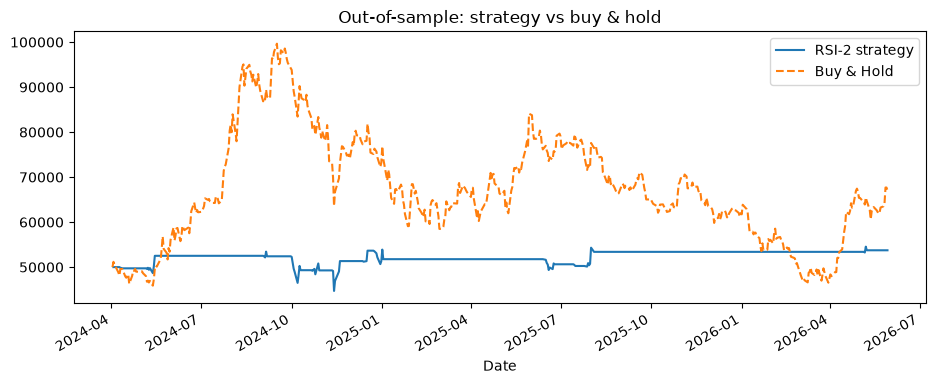

In [41]:
fig, ax = plt.subplots(figsize=(11,4))
(eq_os).plot(ax=ax, label="RSI-2 strategy")
(bh_eq).plot(ax=ax, label="Buy & Hold", linestyle="--")
ax.set_title("Out-of-sample: strategy vs buy & hold")
ax.legend(); plt.show()

### How to read what you just saw

A high **win rate** (often 60%+) feels like skill. It usually isn't. Mean reversion wins *often* but *small* — and while you sit in cash waiting for oversold signals, buy-and-hold captures the big trending moves you miss.

**The bar is not "did I make money." It's "did I beat doing nothing, after costs, on data I didn't fit to."** Most strategies fail that bar. Concluding "this isn't worth trading" is the skill — it's what keeps your money alive.

## 8. Experiment 1 — what do costs actually cost you?

Run with costs, then with costs zeroed. The difference is the tax that trading frequency puts on you. This is the number beginners never see.

In [42]:
def run_oos(cost_on=True, rsi_entry=10):
    global _saved
    import types
    d = add_indicators(get_data())
    s = int(len(d)*0.60)
    if not cost_on:
        orig = cost_fraction_per_side.__code__
    eq, tr = backtest(d.iloc[s:], rsi_entry=rsi_entry, capital=CAP)
    return eq, tr

# with costs
eq_on, tr_on = backtest(df.iloc[split:], capital=CAP)
ret_on = (eq_on.iloc[-1]/CAP-1)*100

# without costs: temporarily monkeypatch the cost function to 0
_real = cost_fraction_per_side
cost_fraction_per_side = lambda: 0.0
eq_off, tr_off = backtest(df.iloc[split:], capital=CAP)
ret_off = (eq_off.iloc[-1]/CAP-1)*100
cost_fraction_per_side = _real   # restore

print(f"Out-of-sample return WITH costs   : {ret_on:7.2f}%")
print(f"Out-of-sample return WITHOUT costs: {ret_off:7.2f}%")
print(f"Costs ate                          : {ret_off-ret_on:7.2f} percentage points")
print(f"...across {len(tr_on)} trades")

Out-of-sample return WITH costs   :    7.48%
Out-of-sample return WITHOUT costs:   14.65%
Costs ate                          :    7.18 percentage points
...across 12 trades


**Lesson:** every trade is a leak. A strategy that looks good "in theory" (no costs) can be a loser in reality. The more it trades, the more it leaks. This is why low-frequency, high-conviction beats hyperactive churning for small accounts.

## 9. Experiment 2 — the overfitting trap, live

Sweep the entry threshold. You'll be *tempted* to pick the value with the best return. **That temptation is overfitting.** A robust edge works across a range of reasonable settings; a fragile one only works at one cherry-picked number that won't repeat.

In [43]:
rows = []
for entry in [5, 8, 10, 12, 15, 20]:
    eq, tr = backtest(df.iloc[split:], rsi_entry=entry, capital=CAP)
    ret = (eq.iloc[-1]/CAP-1)*100
    dd  = ((eq-eq.cummax())/eq.cummax()).min()*100
    win = (tr["ret_pct"]>0).mean()*100 if len(tr) else 0
    rows.append({"rsi_entry": entry, "return_%": ret, "max_dd_%": dd,
                 "trades": len(tr), "win_%": win})
res = pd.DataFrame(rows)
print(res.to_string(index=False))

 rsi_entry  return_%  max_dd_%  trades  win_%
         5     24.41     -6.61       6  66.67
         8     21.79    -13.00      10  70.00
        10      7.48    -16.35      12  58.33
        12     -5.54    -20.38      14  57.14
        15     -0.99    -21.27      18  61.11
        20    -10.76    -27.63      24  54.17


**Lesson:** if the "best" setting makes a lot of money and the neighbours don't, you've found noise, not edge. If results are stable and *mediocre* across settings, that's actually more trustworthy — and here, probably still not good enough to beat buy-and-hold. That conclusion is fine. Knowing it before risking money is the whole job.

## 10. Where to go next

1. **Swap in real data** (yfinance loader in Section 2) on your own machine and run it on RELIANCE, then 4–5 other NSE stocks. Watch results swing wildly across stocks — that instability is the tell that there's no robust edge to lean on.
2. **Monte Carlo (later, done right):** shuffle the trade sequence thousands of times to see how bad the drawdown *could* have been. The –9% you saw might be –20% in an unlucky ordering. That's how you size risk honestly.
3. **Read-only Kite monitor:** reuse this exact rule logic to flag your live holdings — report only, never auto-trade. Build it only once a rule is worth monitoring.

**And in parallel, on your real ₹50k:** pick one holding, set a real GTT stop in Zerodha, and let it execute without overriding it. The backtest just *proved with numbers* that busy trading underperformed sitting still — same lesson your overridden stops keep teaching. Discipline is the edge you can actually control.

## 11. Forward simulation + Monte Carlo (the honest add-ons)

Two tools that fit this system (unlike DCF, which is fundamental valuation and belongs in a separate project):

- **Forward simulator** walks the rule day-by-day, only ever seeing today and earlier. It is paper trading done right - no broker, no real orders, no fake live dashboard. It is the bridge between backtest and real money.
- **Monte Carlo on the trades** (not on prices). Two sims for two questions: *reshuffle* trade order for drawdown-path risk, *bootstrap* (resample with replacement) for how uncertain the return really is given a small sample.

In [44]:
import numpy as np, pandas as pd

def _rsi(s, p=2):
    d=s.diff(); g=d.clip(lower=0); l=-d.clip(upper=0)
    ag=g.ewm(alpha=1/p,adjust=False).mean(); al=l.ewm(alpha=1/p,adjust=False).mean()
    return 100-(100/(1+ag/al.replace(0,np.nan)))

def _cost(): return 0.001+0.0000345+0.18*0.0000345+0.00015+0.000001+0.0015

def forward_simulate(raw, warmup=200, rsi_entry=10, capital=50000):
    c=_cost(); closes=raw["Close"]; dates=raw.index
    cash,shares,inpos,ep,ed=capital,0,False,0.0,None; trades,eqs=[],[]
    for i in range(warmup,len(raw)):
        w=closes.iloc[:i+1]; pt=w.iloc[-1]
        sl=w.tail(200).mean(); se=w.tail(5).mean(); rt=_rsi(w).iloc[-1]
        if not inpos:
            if rt<rsi_entry and pt>sl:
                shares=int(cash//(pt*(1+c)))
                if shares>0: cash-=shares*pt*(1+c); inpos,ep,ed=True,pt,dates[i]
        else:
            if pt>se:
                cash+=shares*pt*(1-c)
                trades.append({"ret_pct":round((pt/ep-1)*100,2)}); shares,inpos=0,False
        eqs.append(cash+shares*pt)
    return pd.Series(eqs,index=dates[warmup:]), pd.DataFrame(trades)

def monte_carlo_trades(rets, n_sims=5000, capital=50000, seed=1):
    rng=np.random.default_rng(seed); r=np.array(rets,float)/100; n=len(r)
    rs_dd=[]
    for _ in range(n_sims):
        eq=np.insert(capital*np.cumprod(1+r[rng.permutation(n)]),0,capital)
        rs_dd.append(((eq-np.maximum.accumulate(eq))/np.maximum.accumulate(eq)).min()*100)
    br,bd=[],[]
    for _ in range(n_sims):
        s=r[rng.integers(0,n,n)]; eq=np.insert(capital*np.cumprod(1+s),0,capital)
        br.append((eq[-1]/capital-1)*100)
        bd.append(((eq-np.maximum.accumulate(eq))/np.maximum.accumulate(eq)).min()*100)
    rs_dd,br,bd=np.array(rs_dd),np.array(br),np.array(bd)
    print(f"Reshuffle  max DD: median {np.median(rs_dd):.2f}% | worst-5% {np.percentile(rs_dd,5):.2f}%")
    print(f"Bootstrap  return: median {np.median(br):.2f}% | 5th {np.percentile(br,5):.2f}% | 95th {np.percentile(br,95):.2f}%")
    print(f"Bootstrap  max DD: median {np.median(bd):.2f}% | worst-5% {np.percentile(bd,5):.2f}%")
    print(f"Prob of losing money: {(br<0).mean()*100:.1f}%")
    return br

eqf, trf = forward_simulate(get_data().iloc[int(len(get_data())*0.6)-200:])
print(f"Forward paper trades: {len(trf)}, final Rs {eqf.iloc[-1]:,.0f}\n")
boot = monte_carlo_trades(trf["ret_pct"])

Forward paper trades: 12, final Rs 49,815

Reshuffle  max DD: median -6.07% | worst-5% -10.02%
Bootstrap  return: median 6.73% | 5th -9.32% | 95th 22.80%
Bootstrap  max DD: median -5.83% | worst-5% -14.25%
Prob of losing money: 25.2%


**The single most important takeaway in this whole notebook:**

The forward sim gives *one* number. The bootstrap shows the *range* that number could have been. When that range spans negative to strongly positive and includes a real chance of losing money, **you do not have enough evidence to conclude the strategy works** - regardless of what any single backtest, or any reel, shows you. Small samples lie. The bootstrap is how you catch the lie.